# Trends, Business Ideas & What Earns More

**Questions:**
1. What trends are growing over time?
2. What business ideas/services are most common?
3. What ideas earn more? (using team size + stage as proxy)

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)

conn = sqlite3.connect("../data/yc_collaboration.db")
df = pd.read_sql("SELECT * FROM companies", conn)
conn.close()

# Parse batch year
df["batch_year"] = df["batch"].str.extract(r"(\d{4})").astype(float)
df["batch_season"] = df["batch"].str.extract(r"(\w+)\s")

# Explode tags into rows
df["tags_list"] = df["tags"].str.split("; ")
tags_df = df.explode("tags_list")
tags_df = tags_df[tags_df["tags_list"].str.strip() != ""]
tags_df = tags_df.dropna(subset=["tags_list"])

print(f"Loaded {len(df)} companies, {len(tags_df)} tag-company pairs")

Loaded 5690 companies, 15313 tag-company pairs


---
## 1. Tag Trends Over Time
Which categories are growing year over year?

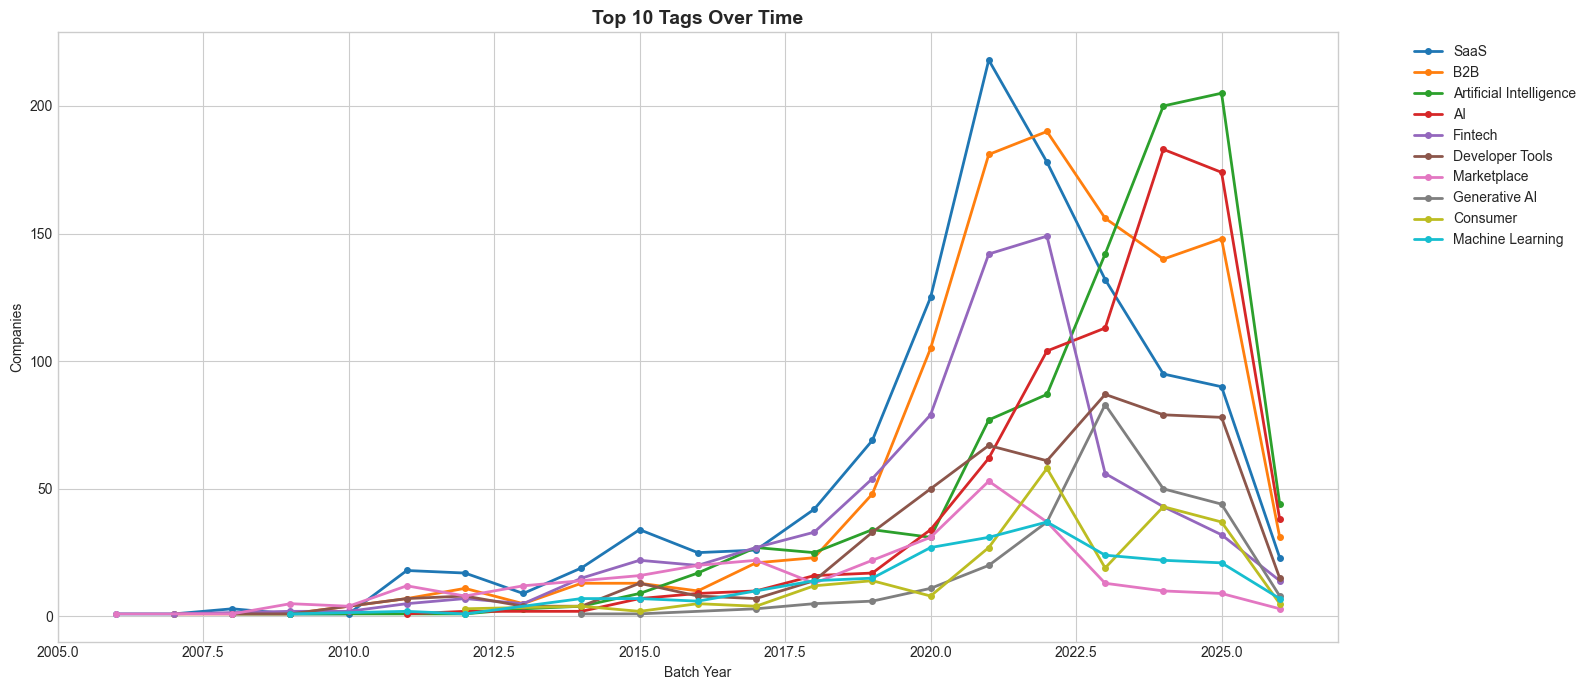

In [4]:
# Count tags per year
tag_year = tags_df.groupby(["batch_year", "tags_list"]).size().reset_index(name="count")

# Top 10 tags overall
top_tags = tags_df["tags_list"].value_counts().head(10).index.tolist()

fig, ax = plt.subplots(figsize=(16, 7))
for tag in top_tags:
    data = tag_year[tag_year["tags_list"] == tag].sort_values("batch_year")
    ax.plot(data["batch_year"], data["count"], marker="o", label=tag, linewidth=2, markersize=4)

ax.set_title("Top 10 Tags Over Time", fontsize=14, fontweight="bold")
ax.set_xlabel("Batch Year")
ax.set_ylabel("Companies")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Fastest Growing Tags (Last 3 Years vs Prior)

In [5]:
recent = tags_df[tags_df["batch_year"] >= 2023]["tags_list"].value_counts()
older = tags_df[(tags_df["batch_year"] >= 2020) & (tags_df["batch_year"] < 2023)]["tags_list"].value_counts()

# Compare: tags that exist in both periods with min 5 in recent
common = recent.index.intersection(older.index)
growth = ((recent[common] - older[common]) / older[common] * 100).sort_values(ascending=False)
growth = growth[recent[common] >= 5]  # filter noise

print("=== Fastest Growing Tags (2023-2026 vs 2020-2022) ===")
print(f"{'Tag':<30} {'2020-22':>8} {'2023-26':>8} {'Growth':>8}")
print("-" * 58)
for tag in growth.head(20).index:
    print(f"{tag:<30} {older.get(tag, 0):>8} {recent.get(tag, 0):>8} {growth[tag]:>7.0f}%")

=== Fastest Growing Tags (2023-2026 vs 2020-2022) ===
Tag                             2020-22  2023-26   Growth
----------------------------------------------------------
Reinforcement Learning                1       28    2700%
Semiconductors                        1       10     900%
Monitoring                            1        9     800%
Industrial                            2       15     650%
Conversational AI                     6       39     550%
Automotive                            2       11     450%
Automation                           12       61     408%
Emerging Markets                      1        5     400%
Design                                4       20     400%
Architecture                          1        5     400%
Legal                                 5       25     400%
Operations                            5       21     320%
Data Science                          5       21     320%
Social Media                          3       12     300%
Electronics      

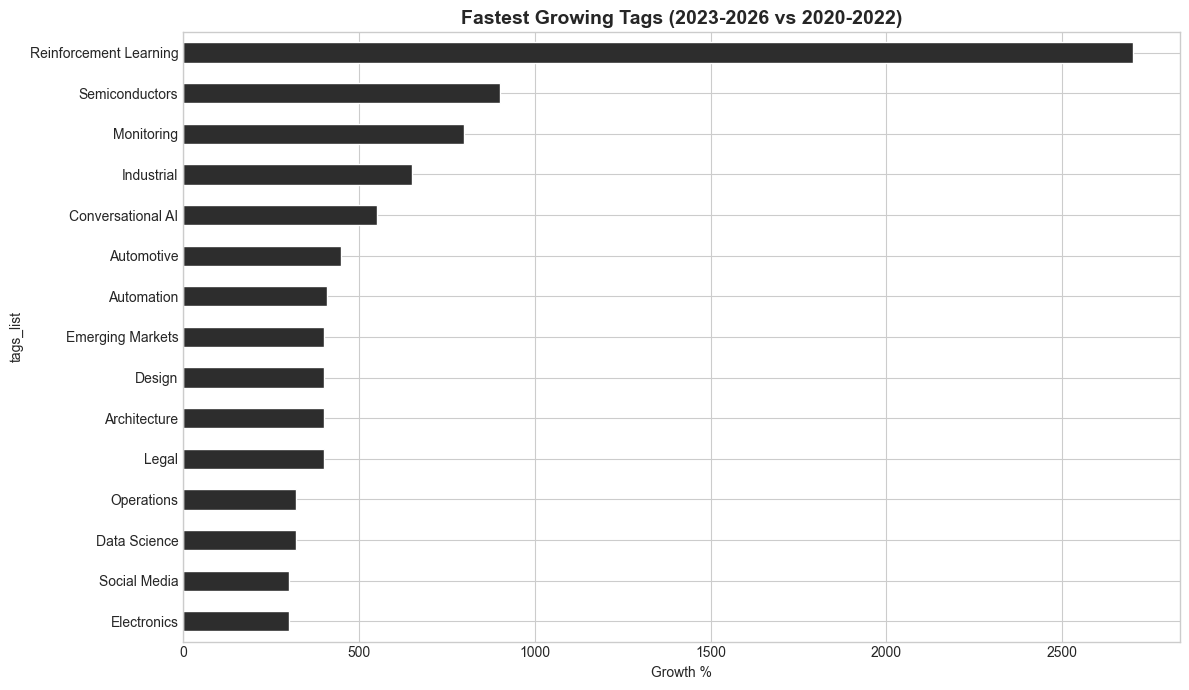

In [6]:
# Visualize top 15 fastest growing
top_growth = growth.head(15)

fig, ax = plt.subplots(figsize=(12, 7))
colors = ["#2d2d2d" if v > 0 else "#999999" for v in top_growth.values]
top_growth.plot(kind="barh", ax=ax, color=colors, edgecolor="white")
ax.set_title("Fastest Growing Tags (2023-2026 vs 2020-2022)", fontsize=14, fontweight="bold")
ax.set_xlabel("Growth %")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### Declining Tags

In [7]:
declining = growth[growth < 0].sort_values()

print("=== Declining Tags (2023-2026 vs 2020-2022) ===")
print(f"{'Tag':<30} {'2020-22':>8} {'2023-26':>8} {'Change':>8}")
print("-" * 58)
for tag in declining.head(15).index:
    print(f"{tag:<30} {older.get(tag, 0):>8} {recent.get(tag, 0):>8} {growth[tag]:>7.0f}%")

=== Declining Tags (2023-2026 vs 2020-2022) ===
Tag                             2020-22  2023-26   Change
----------------------------------------------------------
Medical Devices                      30        5     -83%
Food Tech                            22        5     -77%
Subscriptions                        22        5     -77%
Consumer Health Services             58       15     -74%
E-commerce                           98       28     -71%
Marketplace                         121       35     -71%
Crypto / Web3                        50       15     -70%
Social                               23        7     -70%
Climate                              73       23     -68%
Fintech                             370      145     -61%
Education                            59       25     -58%
Neobank                              32       14     -56%
Health & Wellness                    21       10     -52%
Creator Economy                      18        9     -50%
Therapeutics           

---
## 2. Most Common Business Ideas / Services

In [8]:
# Industry + subindustry breakdown
print("=== Top Industries ===")
print(df["industry"].value_counts().head(10))
print()
print("=== Top Sub-Industries ===")
print(df["subindustry"].value_counts().head(20))

=== Top Industries ===
industry
B2B                             2876
Consumer                         866
Healthcare                       656
Fintech                          607
Industrials                      349
Real Estate and Construction     153
Education                        125
Government                        40
Unspecified                       18
Name: count, dtype: int64

=== Top Sub-Industries ===
subindustry
B2B -> Engineering, Product and Design        585
B2B                                           535
B2B -> Infrastructure                         261
B2B -> Productivity                           219
B2B -> Marketing                              158
Fintech                                       155
Consumer                                      155
Healthcare -> Healthcare IT                   138
B2B -> Operations                             134
B2B -> Sales                                  130
B2B -> Retail                                 129
B2B -> Supply Chain

In [9]:
# Most common tag combinations (business niches)
niche_counts = df[df["tags"] != ""]["tags"].value_counts().head(20)

print("=== Most Common Tag Combinations (Business Niches) ===")
print(f"{'Tags':<60} {'Count':>6}")
print("-" * 68)
for tags, count in niche_counts.items():
    print(f"{tags[:58]:<60} {count:>6}")

=== Most Common Tag Combinations (Business Niches) ===
Tags                                                          Count
--------------------------------------------------------------------
Fintech                                                          83
SaaS                                                             42
SaaS; B2B                                                        41
Marketplace                                                      37
Fintech; SaaS; B2B                                               32
Fintech; SaaS                                                    24
Fintech; Payments                                                22
Artificial Intelligence                                          22
Analytics                                                        21
Developer Tools                                                  21
Education                                                        21
Developer Tools; SaaS; B2B                                  

In [ ]:
# What subindustries are trending recently?
recent_sub = df[df["batch_year"] >= 2023]["subindustry"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 7))
recent_sub.plot(kind="barh", ax=ax, color="#333333", edgecolor="white")
ax.set_title("Most Common Sub-Industries (2023-2026 Batches)", fontsize=14, fontweight="bold")
ax.set_xlabel("Count")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

---
## 3. What Ideas Earn More?

No revenue data available, so we use proxies:
- **Team size** = more funding/revenue (bigger team needs more money)
- **Growth stage** = past product-market fit
- **Active + large team** = strong signal of success

In [10]:
active = df[df["status"] == "Active"].copy()

# Median team size by industry (active only)
industry_size = active.groupby("industry")["team_size"].agg(["median", "mean", "count"]).sort_values("median", ascending=False)
industry_size.columns = ["Median Team", "Mean Team", "Companies"]

print("=== Active Companies: Team Size by Industry ===")
print(industry_size.to_string())

=== Active Companies: Team Size by Industry ===
                              Median Team  Mean Team  Companies
industry                                                       
Fintech                              14.0  71.296629        445
Education                            13.5  80.779070         86
Unspecified                          11.5  42.687500         16
Real Estate and Construction          9.5  41.708333         96
Industrials                           7.5  30.251880        266
Government                            7.0  16.433333         30
Healthcare                            7.0  37.633466        502
B2B                                   6.0  41.096678       2017
Consumer                              6.0  78.755000        400


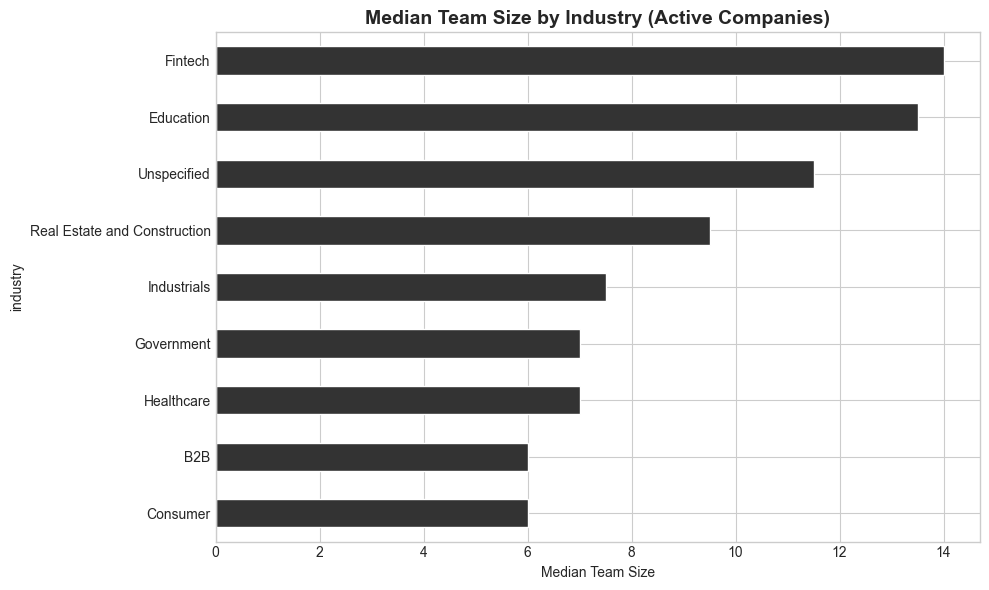

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))
industry_size["Median Team"].plot(kind="barh", ax=ax, color="#333333", edgecolor="white")
ax.set_title("Median Team Size by Industry (Active Companies)", fontsize=14, fontweight="bold")
ax.set_xlabel("Median Team Size")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

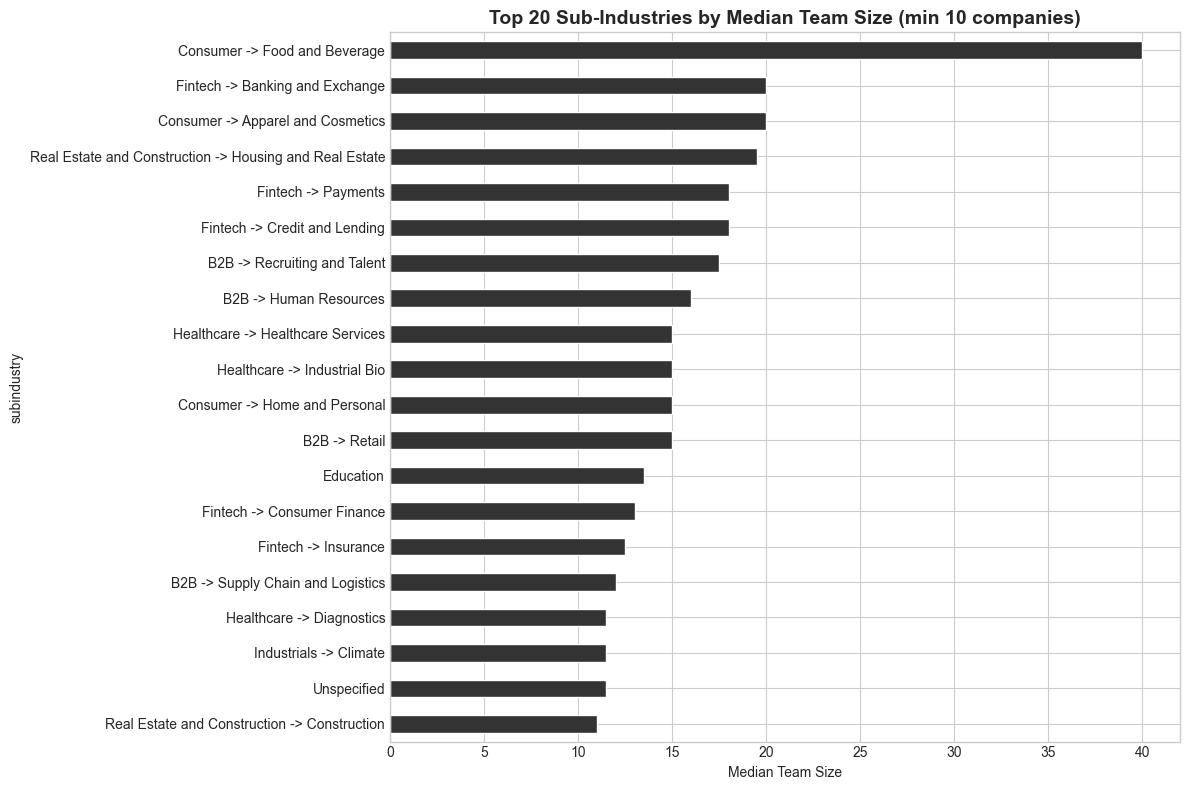

In [12]:
# Median team size by sub-industry (top 20, min 10 companies)
sub_size = active.groupby("subindustry")["team_size"].agg(["median", "mean", "count"])
sub_size = sub_size[sub_size["count"] >= 10].sort_values("median", ascending=False)
sub_size.columns = ["Median Team", "Mean Team", "Companies"]

fig, ax = plt.subplots(figsize=(12, 8))
sub_size["Median Team"].head(20).plot(kind="barh", ax=ax, color="#333333", edgecolor="white")
ax.set_title("Top 20 Sub-Industries by Median Team Size (min 10 companies)", fontsize=14, fontweight="bold")
ax.set_xlabel("Median Team Size")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

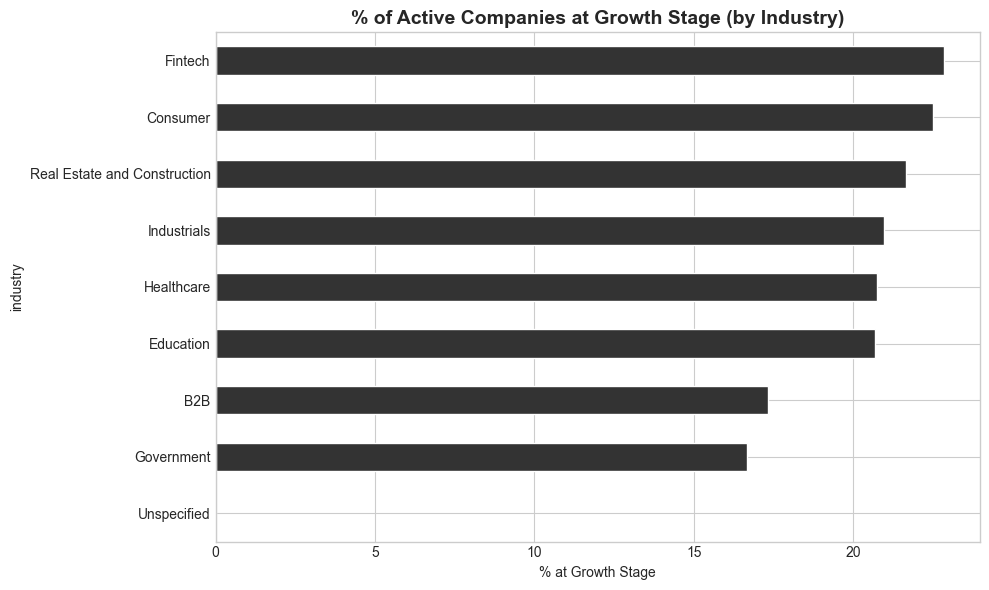

In [13]:
# Growth stage ratio by industry (higher = more companies reached Growth)
stage_ratio = active.groupby("industry").apply(
    lambda g: pd.Series({
        "growth_pct": (g["stage"] == "Growth").mean() * 100,
        "total": len(g)
    })
).sort_values("growth_pct", ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
stage_ratio["growth_pct"].plot(kind="barh", ax=ax, color="#333333", edgecolor="white")
ax.set_title("% of Active Companies at Growth Stage (by Industry)", fontsize=14, fontweight="bold")
ax.set_xlabel("% at Growth Stage")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### Top Tags by Success (Team Size)

In [14]:
# Which tags correlate with bigger companies?
active_tags = tags_df[tags_df["status"] == "Active"].copy()
tag_success = active_tags.groupby("tags_list")["team_size"].agg(["median", "mean", "count"])
tag_success = tag_success[tag_success["count"] >= 15].sort_values("median", ascending=False)
tag_success.columns = ["Median Team", "Mean Team", "Companies"]

print("=== Tags with Largest Median Team Size (min 15 companies) ===")
print(tag_success.head(25).to_string())

=== Tags with Largest Median Team Size (min 15 companies) ===
                      Median Team   Mean Team  Companies
tags_list                                               
Latin America                64.0  372.500000         16
Electric Vehicles            40.0   49.058824         17
Delivery                     40.0  492.586207         29
Grocery                      29.5  441.300000         20
eLearning                    27.0  163.285714         35
Banking as a Service         25.0  475.272727         22
India                        25.0  164.238095         21
IoT                          22.5   54.375000         24
Genomics                     18.0   20.937500         16
Food Tech                    18.0  180.322581         31
E-commerce                   18.0  134.878788        132
Proptech                     16.0   44.612903         62
Climate                      15.5   35.078431        102
HR Tech                      15.0  184.500000         66
Telehealth                

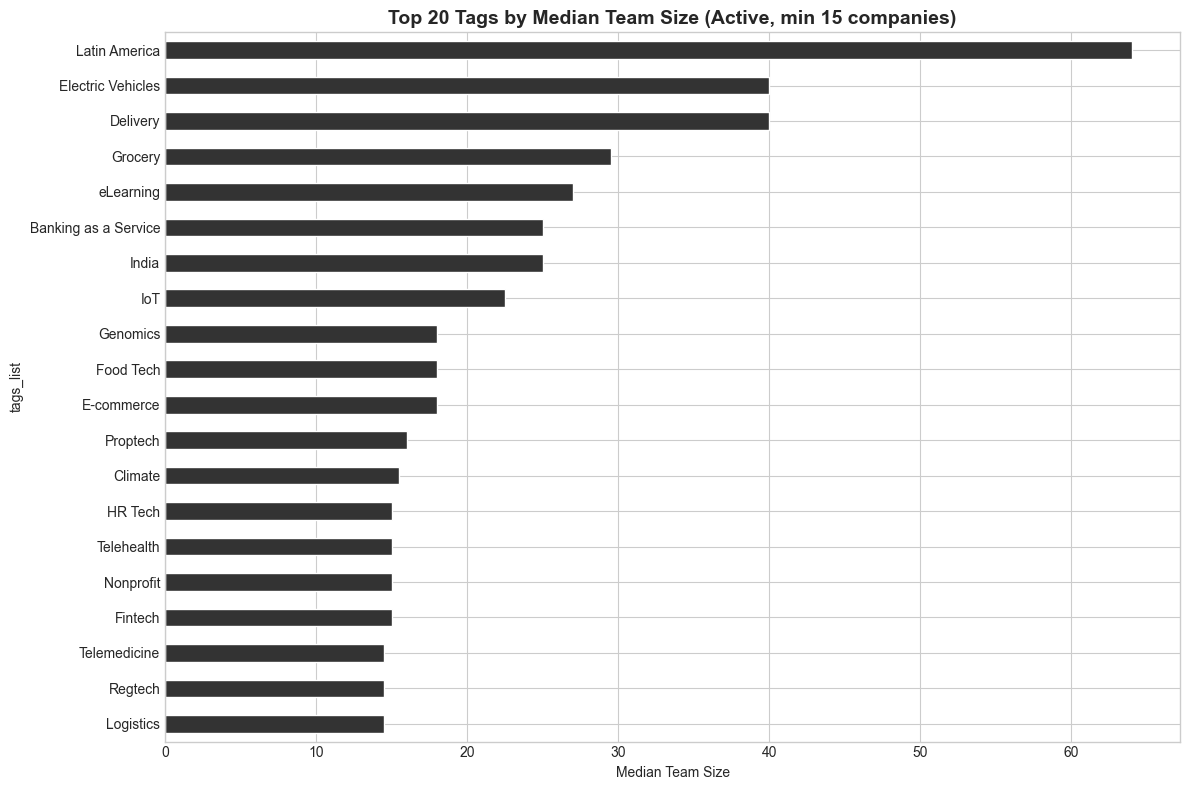

In [15]:
fig, ax = plt.subplots(figsize=(12, 8))
tag_success["Median Team"].head(20).plot(kind="barh", ax=ax, color="#333333", edgecolor="white")
ax.set_title("Top 20 Tags by Median Team Size (Active, min 15 companies)", fontsize=14, fontweight="bold")
ax.set_xlabel("Median Team Size")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### Survival Rate by Tag (Which Ideas Last?)

In [16]:
# Only look at tags with enough data and from batches old enough to measure survival
mature = tags_df[tags_df["batch_year"] <= 2022].copy()  # at least 3+ years old

tag_survival = mature.groupby("tags_list").apply(
    lambda g: pd.Series({
        "survival_rate": (g["status"] == "Active").mean() * 100,
        "total": len(g)
    })
).sort_values("survival_rate", ascending=False)

tag_survival = tag_survival[tag_survival["total"] >= 15]

print("=== Highest Survival Rate by Tag (batches <= 2022, min 15 companies) ===")
print(f"{'Tag':<30} {'Survival %':>12} {'Total':>8}")
print("-" * 52)
for tag, row in tag_survival.head(20).iterrows():
    print(f"{tag:<30} {row['survival_rate']:>11.1f}% {int(row['total']):>8}")

print(f"\n=== Lowest Survival Rate ===")
print(f"{'Tag':<30} {'Survival %':>12} {'Total':>8}")
print("-" * 52)
for tag, row in tag_survival.tail(15).iterrows():
    print(f"{tag:<30} {row['survival_rate']:>11.1f}% {int(row['total']):>8}")

=== Highest Survival Rate by Tag (batches <= 2022, min 15 companies) ===
Tag                              Survival %    Total
----------------------------------------------------
Synthetic Biology                     95.0%       20
AI                                    88.3%      264
Drug discovery                        86.4%       22
Therapeutics                          84.4%       32
Banking as a Service                  84.0%       25
Nonprofit                             84.0%       25
Mental Health Tech                    82.9%       35
Consumer Health Services              82.4%       91
Enterprise Software                   82.1%       39
AI-powered Drug Discovery             81.5%       27
Health Insurance                      81.2%       16
AIOps                                 81.2%       16
AI-Enhanced Learning                  81.0%       21
Hard Tech                             80.7%       57
Space Exploration                     80.0%       15
AI Assistant              

---
## 4. Summary: Best Business Ideas

Combining: trending + large teams + high survival

In [17]:
# Score tags on 3 dimensions: trend growth, team size, survival
from functools import reduce

# Normalize each metric to 0-100
def normalize(series):
    return (series - series.min()) / (series.max() - series.min()) * 100

# Get tags present in all 3 datasets
common_tags = (
    set(growth.index) &
    set(tag_success.index) &
    set(tag_survival.index)
)

scores = pd.DataFrame(index=list(common_tags))
scores["trend_score"] = normalize(growth[scores.index])
scores["size_score"] = normalize(tag_success.loc[scores.index, "Median Team"])
scores["survival_score"] = normalize(tag_survival.loc[scores.index, "survival_rate"])
scores["overall"] = (scores["trend_score"] * 0.35 + scores["size_score"] * 0.35 + scores["survival_score"] * 0.30)
scores = scores.sort_values("overall", ascending=False)

print("=== Top Business Ideas (Trending + Big Teams + High Survival) ===")
print(f"{'Tag':<30} {'Trend':>7} {'Size':>7} {'Survive':>7} {'Overall':>8}")
print("-" * 62)
for tag, row in scores.head(25).iterrows():
    print(f"{tag:<30} {row['trend_score']:>6.1f} {row['size_score']:>6.1f} {row['survival_score']:>7.1f} {row['overall']:>7.1f}")

=== Top Business Ideas (Trending + Big Teams + High Survival) ===
Tag                              Trend    Size Survive  Overall
--------------------------------------------------------------
HR Tech                          12.4   80.0    77.8    55.7
Automation                      100.0    6.7    60.0    55.3
E-commerce                        2.4  100.0    60.0    53.9
Food Tech                         1.2  100.0    57.8    52.8
AIOps                            72.4    6.7    80.6    51.9
Logistics                        14.1   76.7    64.7    51.2
Proptech                          8.4   86.7    58.5    50.8
Climate                           3.0   83.3    66.7    50.2
Enterprise Software              62.9   10.0    81.7    50.0
Infrastructure                   75.9    6.7    70.2    50.0
Fintech                           4.6   80.0    67.2    49.8
ClimateTech                      15.3   63.3    71.8    49.0
Insurance                        16.9   70.0    61.0    48.7
LegalTech     

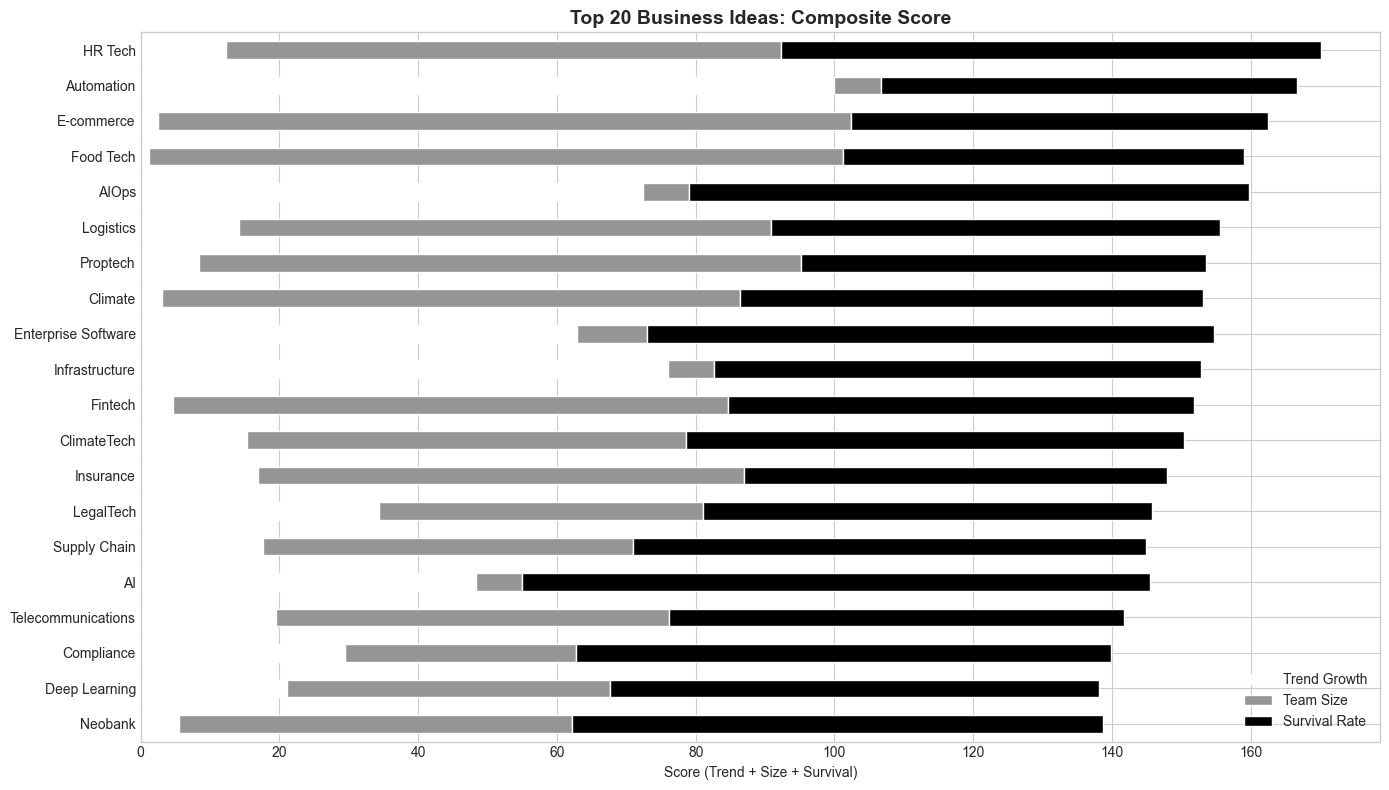

In [18]:
# Visualize top 20
top_scores = scores.head(20)[["trend_score", "size_score", "survival_score"]]

fig, ax = plt.subplots(figsize=(14, 8))
top_scores.plot(kind="barh", stacked=True, ax=ax, colormap="Greys", edgecolor="white")
ax.set_title("Top 20 Business Ideas: Composite Score", fontsize=14, fontweight="bold")
ax.set_xlabel("Score (Trend + Size + Survival)")
ax.invert_yaxis()
ax.legend(["Trend Growth", "Team Size", "Survival Rate"], loc="lower right")
plt.tight_layout()
plt.show()